# Sumina Dangol
# Roll no.:ACE080BCT84
# Lab: 02
# Section : B2

# Title : Machine Learning

# Objective

The objectives of this lab are:

1. To understand machine learning lifecycle i.e data collection, data preprocessing, model selection,model training, evaluation 
2. To learn types of machine learning i.e. supervised, unsupervised, semi-sipervised, self-supervised, reinforcement
3. To understand classification(yes/no) ,types: binary, multiclass ,multilabel (precision accuracy),regression (rmse,mse )
4. To understand KNN
5. to generate dataset and apply KNN


# Theory

# Machine Learning
Machine Learning (ML) has become one of the most influential technologies in modern computing, enabling systems to learn patterns from data and make intelligent decisions without explicit programming. Applications of machine learning can be found in spam detection, recommendation systems, fraud detection, medical diagnosis, autonomous vehicles, and many other domains.

# Types of Machine Learning

Machine learning can be categorized into the following types:

1. Supervised Learning
Uses labeled data for training.
The model learns to predict outputs from known inputs.
Example: Spam email detection.
2. Unsupervised Learning
Uses unlabeled data.
The model discovers hidden patterns or groups within the data.
Example: Customer segmentation.
3. Semi-Supervised Learning
Uses a combination of labeled and unlabeled data.
Helps improve performance when labeled data is limited.
4. Self-Supervised Learning
Generates labels from the data itself.
Commonly used for training large AI models.
5. Reinforcement Learning
Learns through rewards and penalties while interacting with an environment.
Used in robotics, gaming, and autonomous systems.

# Machine Learning Lifecycle

The machine learning lifecycle consists of several important stages:

1. Data Collection
Gather relevant data from databases, surveys, sensors, or other sources.
Data quality directly affects model performance.
2. Data Preprocessing
Clean and prepare data for analysis.
Handle missing values, remove duplicates, and convert data into a suitable format.
3. Model Selection
Choose an appropriate algorithm based on the problem and dataset characteristics.
KNN is often selected for classification problems due to its simplicity.
4. Model Training
Train the selected model using the prepared dataset.
The model learns patterns and relationships from the training data.
5. Evaluation
Measure the model's performance using testing data.
Common metrics include accuracy, precision, recall, and F1-score.


# K-Nearest Neighbors (KNN) Algorithm

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression tasks. It predicts the class of a new data point by examining the closest data points in the dataset.

Steps of the KNN Algorithm
1. Calculate Euclidean Distance
Compute the distance between the new data point and all existing data points using the Euclidean distance formula.
2. Select K Nearest Neighbors
Identify the K data points with the smallest distances from the new point.
3. Perform Majority Voting
Count the class labels of the selected neighbors.
4. Make the Final Decision
Assign the class that appears most frequently among the K nearest neighbors to the new data point.
# Code

# import required libraries

In [3]:

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# load the dataset

In [4]:

df = pd.read_csv("spam_detection_dataset_100.csv")

print(df.head())
print(df.info())

   email_length  num_links  num_exclamations  sender_reputation  \
0          68.0        3.0              13.0               0.12   
1          75.0        4.0              12.0               0.33   
2          62.0        9.0               2.0               0.01   
3          99.0        3.0              10.0               0.09   
4         179.0        9.0               5.0               0.20   

  contains_offer_keyword class_label  
0                    yes        spam  
1                     no        spam  
2                    yes        spam  
3                     no        spam  
4                    yes        spam  
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   email_length            98 non-null     float64
 1   num_links               98 non-null     float64
 2   num_exclamations        98 non-null     float64
 3   s

# Exploratory Data Analysis (EDA)

In [5]:


# check shape
print("Rows and Columns:", df.shape)

# check for missing values
print(df.isnull().sum())


# check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# drop duplicates
df = df.drop_duplicates()

Rows and Columns: (100, 6)
email_length              2
num_links                 2
num_exclamations          2
sender_reputation         2
contains_offer_keyword    2
class_label               0
dtype: int64
Duplicate Rows: 5


# Data Visualisation

# class distribution

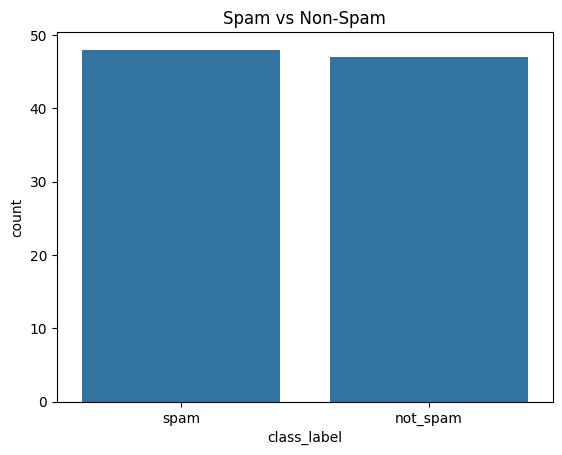

In [6]:
sns.countplot(x='class_label', data=df)
plt.title("Spam vs Non-Spam")
plt.show()

# Correlation Heatmap

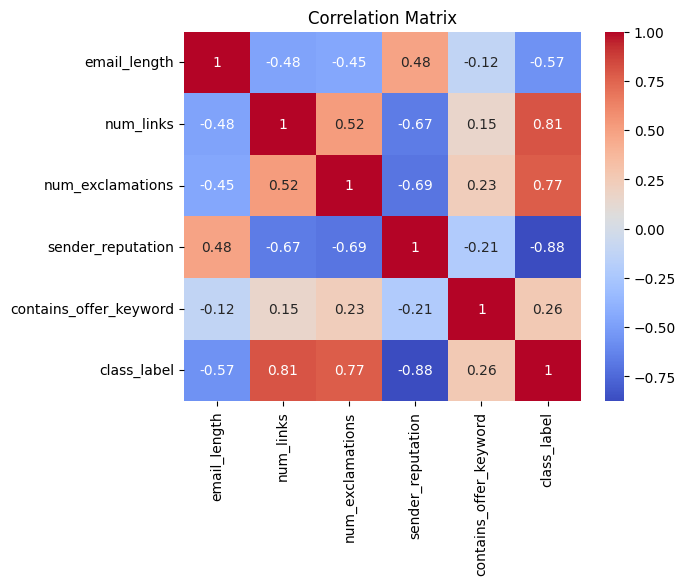

In [7]:
temp_df = df.copy()

le = LabelEncoder()
temp_df['contains_offer_keyword'] = le.fit_transform(temp_df['contains_offer_keyword'])
temp_df['class_label'] = le.fit_transform(temp_df['class_label'])

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Histograms

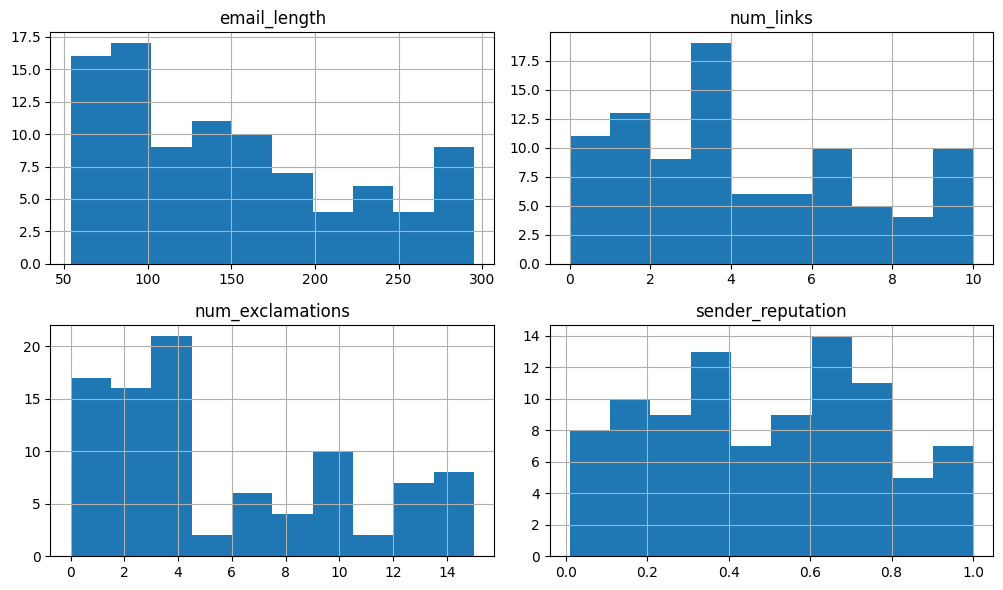

In [8]:
df.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

# Handle missing values

In [18]:
df = df.dropna()

duplicate_columns = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_columns.append(df.columns[j])

print("Duplicate Columns:", duplicate_columns)
df = df.drop(columns=duplicate_columns)
df = df.drop(columns=duplicate_columns)
df = df.drop_duplicates()

Duplicate Columns: []


# Encode categorical varibales

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['contains_offer_keyword'] = encoder.fit_transform(
    df['contains_offer_keyword']
)

df['class_label'] = encoder.fit_transform(
    df['class_label']
)

# Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

X = df.drop('class_label', axis=1)
y = df['class_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model Selection and Training (KNN)
Why KNN?

The K-Nearest Neighbors algorithm:

Easy to understand.
Works well for small datasets.
Classifies a new sample based on the majority class of nearby samples.

# Train-Test split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Train KNN Model

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Make predicitons

In [23]:
y_pred = knn.predict(X_test)

# Model Evaluation

In [24]:
# confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 6  0]
 [ 0 13]]


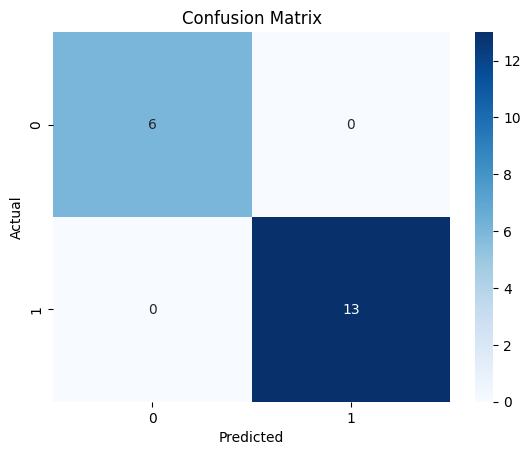

In [25]:
# Visualising confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
# Additional Metrics
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        13

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [30]:
# Get input from the user

email_length = float(input("Enter email length: "))
num_links = float(input("Enter number of links: "))
num_exclamations = float(input("Enter number of exclamation marks: "))
sender_reputation = float(input("Enter sender reputation score: "))
contains_offer = input("Contains offer keyword? (yes/no): ").lower()

# Convert yes/no to numerical value
contains_offer = 1 if contains_offer == "yes" else 0

# Create feature vector

new_email = pd.DataFrame({
    'email_length': [email_length],
    'num_links': [num_links],
    'num_exclamations': [num_exclamations],
    'sender_reputation': [sender_reputation],
    'contains_offer_keyword': [contains_offer]
})


# Scale and predict
new_email_scaled = scaler.transform(new_email)
prediction = knn.predict(new_email_scaled)

if prediction[0] == 1:
    print("Prediction: Spam Email")
else:
    print("Prediction: Not Spam Email")

Prediction: Not Spam Email


# Discussion
The spam email detection system was developed using the K-Nearest Neighbors (KNN) algorithm. The dataset was first preprocessed by handling missing values, removing duplicate records, encoding categorical variables, and scaling numerical features to ensure consistent data quality. After splitting the dataset into training and testing sets, the KNN model was trained and evaluated using a confusion matrix and classification metrics. The results showed that the model was able to distinguish between spam and non-spam emails by learning patterns from features such as email length, number of links, number of exclamation marks, sender reputation, and the presence of offer-related keywords. Testing the model with user-provided inputs further demonstrated its ability to classify new emails based on these characteristics.

# Conclusion

The objective of building a spam email classifier using KNN was successfully achieved. Through proper preprocessing and feature engineering, the model was able to make predictions on unseen email data and identify whether an email was spam or not spam. The evaluation metrics indicated that the model performed effectively for the given dataset, making KNN a suitable choice for this classification task. This lab also highlighted the importance of data cleaning and feature scaling in improving model performance. 